In [1]:
from pathlib import Path
import os
import sys

import numpy as np
import matplotlib.pyplot as plt

def find_repo_root(start: Path) -> Path:
    for path in [start, *start.parents]:
        if (path / "pyproject.toml").exists():
            return path
    raise FileNotFoundError(
        "Could not find repo root (pyproject.toml). Set SYSSIMX_REPO_ROOT."
    )

repo_root = Path(os.environ.get("SYSSIMX_REPO_ROOT", ""))
if repo_root and repo_root.exists():
    repo_root = repo_root.resolve()
else:
    repo_root = find_repo_root(Path.cwd())
sys.path.insert(0, str(repo_root))  # .../SystemSimulation
from syssimx_examples.controlled_pendulum.components import (
    OpenSimPendulum,
    FEMPendulum,
)
from syssimx_examples.controlled_pendulum import MasterPendulum
import syssimx_examples.controlled_pendulum.components.fem.pendulum_config as config
from thesis.plot_setup import set_professional_style
plt = set_professional_style()

platform = sys.platform
print(platform)

linux


In [2]:
repo_root

PosixPath('/home/flo/code/SystemSimulation')

In [3]:
from thesis.plot_setup import set_professional_style
plt = set_professional_style()

# from demos.ControlledPendulum.scripts.update_fmus import get_fmu_paths

**Generate FMUComponents**

In [ ]:
from syssimx.components.fmu import FMUComponent

demo_dir_path = Path(repo_root / "demos" / "ControlledPendulum")
package_path = Path(demo_dir_path / "src/modelica/ControlledPendulum")
fmu_output_dir = Path(demo_dir_path / f"artifacts/fmus/{platform}")

fmu_paths = {}
for subdir in fmu_output_dir.iterdir():
    if subdir.is_dir():
        fmu_paths[subdir.name] = {}
        for fmu_file in subdir.glob("*.fmu"):
            fmu_paths[subdir.name][fmu_file.stem] = fmu_file
    else:
        fmu_paths[subdir.stem] = subdir

In [5]:
set_point = FMUComponent(name="SetPoint",
                         fmu_path=fmu_paths['Trajectories']['SineAngleSetPoint'],
                         group="Control")

In [6]:
angle_sensor = FMUComponent(name="AngleSensor",
                            fmu_path=fmu_paths['Sensors']['AnglePotentiometerADC'],
                            group="Sensors")

In [7]:
decoder = FMUComponent(name="Decoder",
                       fmu_path=fmu_paths['Sensors']['AnglePotentiometerADCDecoder'],
                       group="Control")

In [8]:
pid = FMUComponent(name="PIDController",
                   fmu_path=fmu_paths['Controllers']['PIDContinuous_cvode'],
                     group="Control")


In [9]:
drive = FMUComponent(name="Drive",
                     fmu_path=fmu_paths['Actuators']['DriveDynamic'],
                     group="Actuator")

In [10]:
pendulum = FMUComponent(name="Pendulum",
                        fmu_path=fmu_paths['Plants']['Pendulum_cvode'],
                        group="Plant")

In [11]:
fmu_list = [set_point, angle_sensor, decoder, pid, drive, pendulum]
for fmu in fmu_list:
    print(fmu.name)
    print(" Direct Feedthrough:")
    for output, inputs in fmu.direct_feedthrough.items():
        print(f"  Output: {output} <- Inputs: {inputs}")
    print()

SetPoint
 Direct Feedthrough:
  Output: theta_ref <- Inputs: set()

AngleSensor
 Direct Feedthrough:
  Output: v_out <- Inputs: {'theta'}

Decoder
 Direct Feedthrough:
  Output: theta <- Inputs: {'v_in'}

PIDController
 Direct Feedthrough:
  Output: I_out <- Inputs: set()
  Output: u <- Inputs: {'theta_ref', 'theta_meas'}

Drive
 Direct Feedthrough:
  Output: torque <- Inputs: {'omega'}

Pendulum
 Direct Feedthrough:
  Output: alpha <- Inputs: {'tau'}
  Output: omega <- Inputs: set()
  Output: theta <- Inputs: set()



In [12]:
from syssimx.system.connection import Connection

c1 = Connection(
    src_comp=set_point.name,
    src_port=set_point.output_specs["theta_ref"].name,
    dst_comp=pid.name,
    dst_port=pid.input_specs["theta_ref"].name,
)

c2 = Connection(
    src_comp=pendulum.name,
    src_port=pendulum.output_specs["theta"].name,
    dst_comp=angle_sensor.name,
    dst_port=angle_sensor.input_specs["theta"].name,
)

c3 = Connection(
    src_comp=angle_sensor.name,
    src_port=angle_sensor.output_specs["v_out"].name,
    dst_comp=decoder.name,
    dst_port=decoder.input_specs["v_in"].name,
)

c4 = Connection(
    src_comp=decoder.name,
    src_port=decoder.output_specs["theta"].name,
    dst_comp=pid.name,
    dst_port=pid.input_specs["theta_meas"].name,
)

c5 = Connection(
    src_comp=pid.name,
    src_port=pid.output_specs["u"].name,
    dst_comp=drive.name,
    dst_port=drive.input_specs["u_control"].name,
)

c6 = Connection(
    src_comp=drive.name,
    src_port=drive.output_specs["torque"].name,
    dst_comp=pendulum.name,
    dst_port=pendulum.input_specs["tau"].name,
)

c7 = Connection(
    src_comp=pendulum.name,
    src_port=pendulum.output_specs["omega"].name,
    dst_comp=drive.name,
    dst_port=drive.input_specs["omega"].name,
)

connections = [c1, c2, c3, c4, c5, c6, c7]
components = [set_point, angle_sensor, decoder, pid, drive, pendulum]

In [13]:
from syssimx.system.system import System

system = System(name="Controlled Pendulum System")

for comp in components:
    system.add_component(comp)

for conn in connections:
    system.add_connection(conn)

system.initialize(t0=0.0)

LOG_SOLVER        | info    | CVODE linear multistep method CV_BDF
LOG_SOLVER        | info    | CVODE maximum integration order CV_ITER_NEWTON
LOG_SOLVER        | info    | CVODE use equidistant time grid YES
LOG_SOLVER        | info    | CVODE Using relative error tolerance 1.000000e-06
LOG_SOLVER        | info    | CVODE Using dense internal linear solver SUNLinSol_Dense.
LOG_SOLVER        | info    | CVODE Use internal dense numeric jacobian method.
LOG_SOLVER        | info    | CVODE uses internal root finding method NO
LOG_SOLVER        | info    | CVODE maximum absolut step size 0
LOG_SOLVER        | info    | CVODE initial step size is set automatically
LOG_SOLVER        | info    | CVODE maximum integration order 5
LOG_SOLVER        | info    | CVODE maximum number of nonlinear convergence failures permitted during one step 10
LOG_SOLVER        | info    | CVODE BDF stability limit detection algorithm OFF
LOG_SOLVER        | info    | CVODE linear multistep method CV_BDF
LOG_S

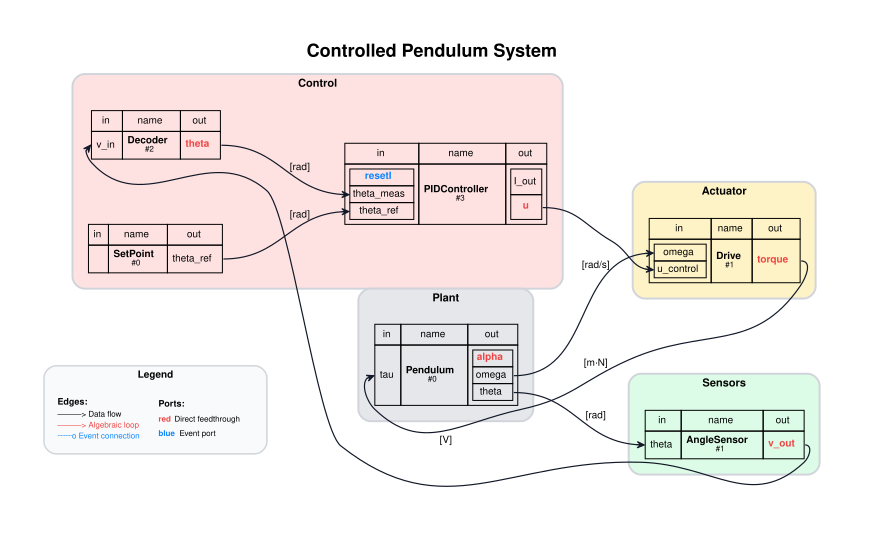

In [14]:
from syssimx.viz.system_graph_visualizer import SystemGraphVisualizer

visualizer = SystemGraphVisualizer(system)
visualizer.visualize()

In [15]:
t = 0.0
t_end = 10.0
dt = 0.001

system.run(t, t_end, dt)
history = system.get_history()

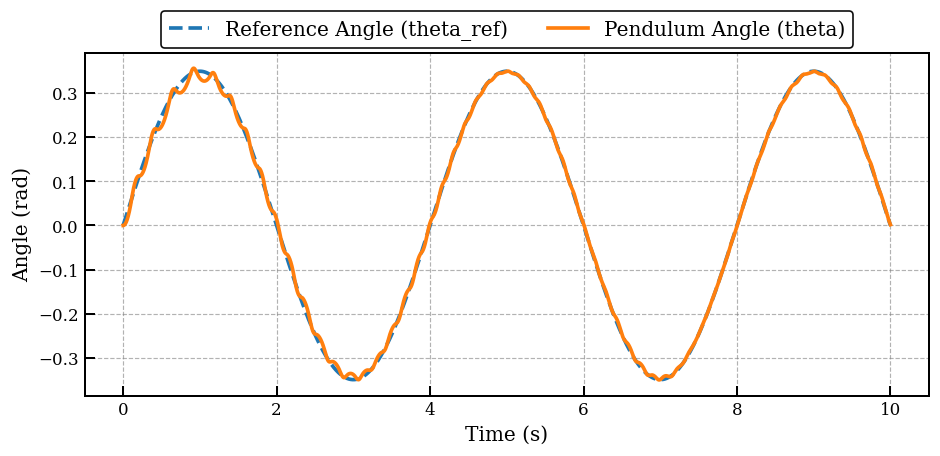

In [16]:
t_setpoint, data = history['SetPoint']
theta_ref = data['theta_ref']
t_pendulum, data = history['Pendulum']
theta = data['theta']

plt.figure(figsize=(8, 4))
plt.plot(t_setpoint, theta_ref, label='Reference Angle (theta_ref)', linestyle='--')
plt.plot(t_pendulum, theta, label='Pendulum Angle (theta)')
plt.xlabel('Time (s)')
plt.ylabel('Angle (rad)')
plt.legend(loc='upper center', bbox_to_anchor=(0.5, 1.15), ncol=2)
plt.grid()
plt.tight_layout()
plt.show()

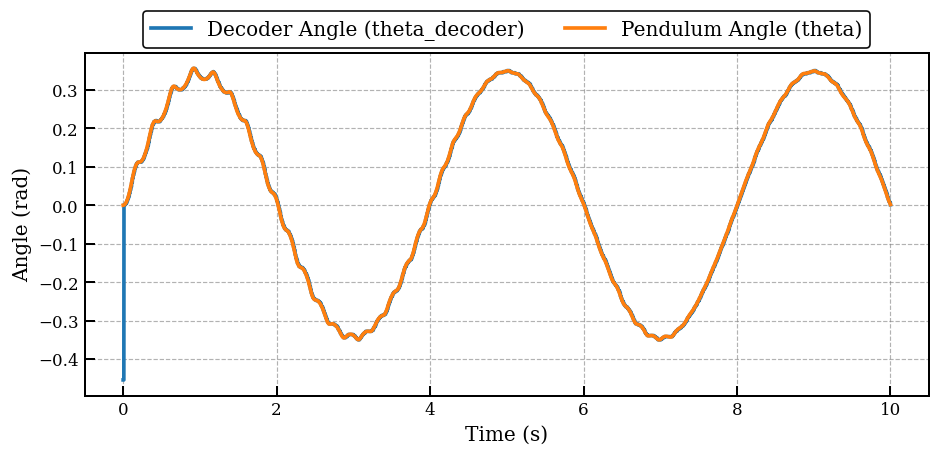

In [17]:
t_decoder, data = history['Decoder']
theta_decoder = data['theta']
t_pendulum, data = history['Pendulum']
theta = data['theta']

plt.figure(figsize=(8, 4))
plt.plot(t_decoder, theta_decoder, label='Decoder Angle (theta_decoder)')
plt.plot(t_pendulum, theta, label='Pendulum Angle (theta)')
plt.xlabel('Time (s)')
plt.ylabel('Angle (rad)')
plt.legend(loc='upper center', bbox_to_anchor=(0.5, 1.15), ncol=2)
plt.grid()
plt.tight_layout()
plt.show()

-------------

In [5]:
import logging

In [9]:
mylogger = logging.getLogger("MyLogger")
mylogger.info("This is an info message.")
mylogger.warning("This is a warning message.")
mylogger.error("This is an error message.")
mylogger.debug("This is a debug message that won't be shown by default.")

INFO:MyLogger:This is an info message.
ERROR:MyLogger:This is an error message.


In [10]:
mylogger.setLevel(logging.DEBUG)  # Set logger to show debug messages

In [11]:
mylogger.info("This is an info message.")
mylogger.warning("This is a warning message.")
mylogger.error("This is an error message.")
mylogger.debug("This is a debug message that won't be shown by default.")

INFO:MyLogger:This is an info message.
ERROR:MyLogger:This is an error message.
DEBUG:MyLogger:This is a debug message that won't be shown by default.
